# HyperBench Tutorial 01: Quickstart

This notebook presents a minimal HyperBench workflow for fusion-based hyperspectral super-resolution.

The notation used throughout the tutorial series is:

- ground-truth hyperspectral image (GT HSI / HR HSI): `(H, W, C)`
- low-resolution hyperspectral image (LR HSI): `(H/r, W/r, C)`
- high-resolution multispectral image (HR MSI): `(H, W, c)`
- spectral response function (SRF): `(c, C)`
- point spread function (PSF): `(k, k)`

This notebook covers:

- loading a hyperspectral scene from a MATLAB file
- normalizing and inspecting the scene
- generating one synthetic LR HSI / HR MSI pair
- running a simple baseline reconstruction pipeline
- computing evaluation metrics

## Related documentation

- `docs/index.md`
- `docs/quickstart.md`
- `docs/core-concepts.md`

## Imports

In [1]:
from pathlib import Path

import cv2
import numpy as np

from hyperbench import (
    __version__,
    evaluate_metrics,
    load_hsi,
    make_psf,
    normalize_image,
    print_data_stats,
    spatial_degradation,
    spectral_degradation,
    visualize_hsi,
    visualize_multispectral_with_srf,
)

print("HyperBench version:", __version__)

HyperBench version: 0.1.0


## Scene configuration

Set the path to a MATLAB scene file and the corresponding variable key.

In [2]:
SCENE_PATH = Path("../data/DC_data.mat")
SCENE_KEY = "dc"

print("Scene path:", SCENE_PATH)
print("Scene key:", SCENE_KEY)

Scene path: ../data/DC_data.mat
Scene key: dc


## Load the scene

HyperBench expects hyperspectral scenes in channel-last format:

- `H`: height
- `W`: width
- `C`: hyperspectral channels

In [3]:
scene = load_hsi(SCENE_PATH, key=SCENE_KEY)
print_data_stats(scene, name="Loaded scene")
print("Loaded shape (H, W, C):", scene.shape)

Loaded scene type: <class 'numpy.ndarray'>
Loaded scene dtype: float32
Loaded scene shape (H, W, B): (1280, 307, 191)
Loaded scene min: -32728.0
Loaded scene max: 32701.0
Loaded scene mean: 2009.333740234375
Loaded scene std: 2266.9697265625
Loaded shape (H, W, C): (1280, 307, 191)


## Normalize the scene

The normalized scene is used as the ground-truth hyperspectral image.

In [4]:
gt_hsi = normalize_image(scene)
print_data_stats(gt_hsi, name="Normalized ground truth")
print("Ground-truth HSI shape (H, W, C):", gt_hsi.shape)

Normalized ground truth type: <class 'numpy.ndarray'>
Normalized ground truth dtype: float32
Normalized ground truth shape (H, W, B): (1280, 307, 191)
Normalized ground truth min: 0.0
Normalized ground truth max: 1.0
Normalized ground truth mean: 0.2233569175004959
Normalized ground truth std: 0.24737973511219025
Ground-truth HSI shape (H, W, C): (1280, 307, 191)


## Visualize the ground-truth scene

An RGB composite is formed by selecting three representative hyperspectral channels.

RGB channel indices: (50, 35, 15)


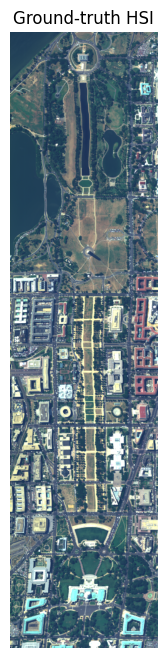

In [5]:
rgb_channels = (50, 35, 15)

print("RGB channel indices:", rgb_channels)
visualize_hsi(gt_hsi, bands=rgb_channels, title="Ground-truth HSI")

## Create one synthetic degradation case

This example uses:

- Gaussian PSF
- downsampling ratio `r = 4`
- multispectral channel count `c = 4`
- spatial SNR = 35 dB
- spectral SNR = 40 dB

In [6]:
psf_name = "gaussian"
psf_sigma = 3.4
psf_kernel_radius = 7

downsample_ratio = 4
spatial_snr_db = 35.0

msi_channel_count = 4
spectral_snr_db = 40.0

psf = make_psf(psf_name, sigma=psf_sigma, kernel_radius=psf_kernel_radius)

lr_hsi = spatial_degradation(
    image=gt_hsi,
    psf=psf,
    downsample_ratio=downsample_ratio,
    snr_db=spatial_snr_db,
)

hr_msi, srf, band_specs, wavelengths = spectral_degradation(
    image=gt_hsi,
    snr_db=spectral_snr_db,
    num_bands=msi_channel_count,
)

print_data_stats(lr_hsi, name="LR HSI")
print_data_stats(hr_msi, name="HR MSI")

print("GT HSI shape (H, W, C):", gt_hsi.shape)
print("LR HSI shape (H/r, W/r, C):", lr_hsi.shape)
print("HR MSI shape (H, W, c):", hr_msi.shape)
print("PSF shape (k, k):", psf.shape)
print("SRF shape (c, C):", srf.shape)

LR HSI type: <class 'numpy.ndarray'>
LR HSI dtype: float32
LR HSI shape (H, W, B): (320, 76, 191)
LR HSI min: -0.015531606040894985
LR HSI max: 1.0333486795425415
LR HSI mean: 0.2211996167898178
LR HSI std: 0.22443662583827972
HR MSI type: <class 'numpy.ndarray'>
HR MSI dtype: float32
HR MSI shape (H, W, B): (1280, 307, 4)
HR MSI min: -0.0006231744191609323
HR MSI max: 1.0127507448196411
HR MSI mean: 0.2644492983818054
HR MSI std: 0.22760891914367676
GT HSI shape (H, W, C): (1280, 307, 191)
LR HSI shape (H/r, W/r, C): (320, 76, 191)
HR MSI shape (H, W, c): (1280, 307, 4)
PSF shape (k, k): (15, 15)
SRF shape (c, C): (4, 191)


## Visualize the degraded inputs

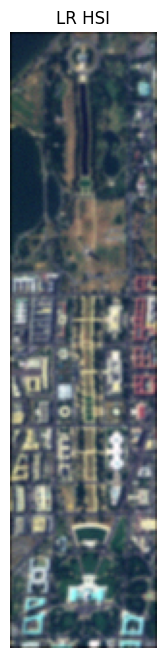

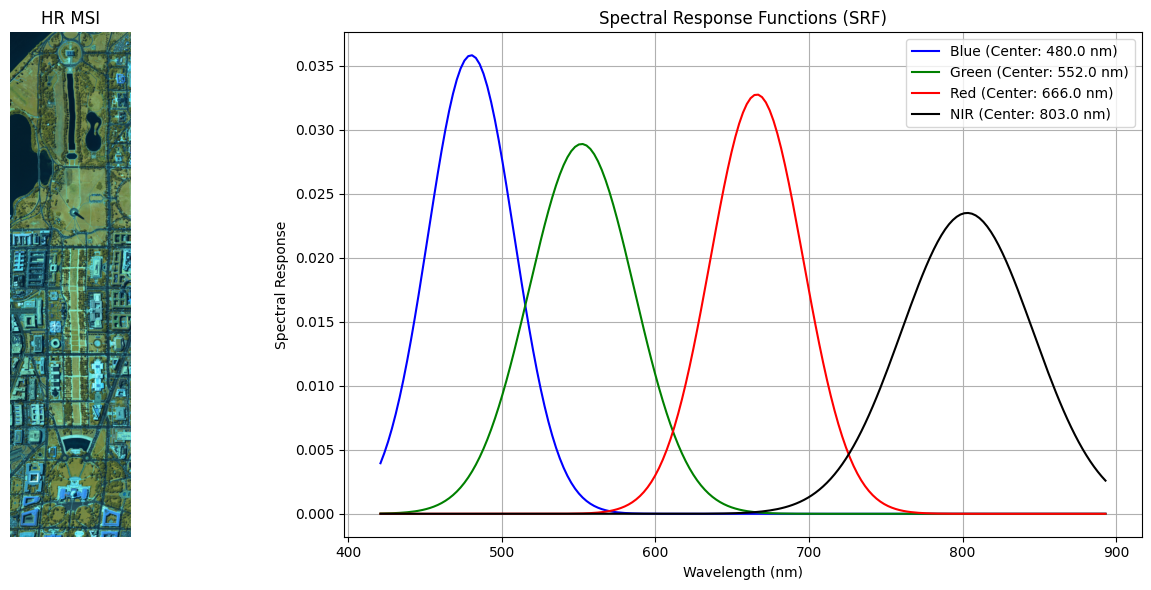

In [7]:
lr_rgb_channels = (50, 35, 15)

visualize_hsi(lr_hsi, bands=lr_rgb_channels, title="LR HSI")

visualize_multispectral_with_srf(
    ms_image=hr_msi,
    bands = (2, 1, 0) if hr_msi.shape[2] in (3, 4) else (4, 2, 1) if hr_msi.shape[2] > 4 else None,
    title="HR MSI",
    srf=srf,
    wavelengths=wavelengths,
    band_specs=band_specs,
)

## Define a simple baseline pipeline

This baseline resizes the LR HSI back to the ground-truth spatial shape using nearest-neighbor interpolation, channel by channel.

It is intentionally simple. The point here is to show the mechanics of the evaluation flow while keeping the reconstruction logic transparent.

In [8]:
def nearest_resize_baseline(HR_MSI, LR_HSI, srf, psf=None, metadata=None):
    target_h = int(metadata["target_shape"][0])
    target_w = int(metadata["target_shape"][1])

    _, _, c_hsi = LR_HSI.shape
    pred = np.empty((target_h, target_w, c_hsi), dtype=np.float32)

    for ch in range(c_hsi):
        pred[:, :, ch] = cv2.resize(
            LR_HSI[:, :, ch],
            (target_w, target_h),
            interpolation=cv2.INTER_NEAREST,
        )

    return pred

## Run the baseline

In [9]:
metadata = {
    "downsample_ratio": downsample_ratio,
    "target_shape": gt_hsi.shape,
    "msi_channel_count": msi_channel_count,
    "spatial_snr_db": spatial_snr_db,
    "spectral_snr_db": spectral_snr_db,
}

prediction = nearest_resize_baseline(
    HR_MSI=hr_msi,
    LR_HSI=lr_hsi,
    srf=srf,
    psf=psf,
    metadata=metadata,
)

print_data_stats(prediction, name="Baseline prediction")
print("Prediction shape:", prediction.shape)
print("Ground-truth shape:", gt_hsi.shape)

Baseline prediction type: <class 'numpy.ndarray'>
Baseline prediction dtype: float32
Baseline prediction shape (H, W, B): (1280, 307, 191)
Baseline prediction min: -0.015531606040894985
Baseline prediction max: 1.0333486795425415
Baseline prediction mean: 0.22092276811599731
Baseline prediction std: 0.2242964804172516
Prediction shape: (1280, 307, 191)
Ground-truth shape: (1280, 307, 191)


## Clip the prediction to `[0, 1]`

HyperBench supports clipping before metric computation so that the prediction range matches the normalized ground truth.

In [10]:
prediction = np.clip(prediction, 0.0, 1.0)
print_data_stats(prediction, name="Clipped prediction")

Clipped prediction type: <class 'numpy.ndarray'>
Clipped prediction dtype: float32
Clipped prediction shape (H, W, B): (1280, 307, 191)
Clipped prediction min: 0.0
Clipped prediction max: 1.0
Clipped prediction mean: 0.2209237664937973
Clipped prediction std: 0.2242930829524994


## Evaluate metrics

In [11]:
metrics = evaluate_metrics(gt_hsi, prediction)

for name, value in metrics.items():
    print(f"{name}: {value}")

RMSE: 0.08892560556457935
PSNR: 21.013351424803098
SSIM: 0.6430002546464616
UIQI: 0.9052681897860407
ERGAS: 9.8009777170259
SAM: 8.514793395996094


## Visual comparison

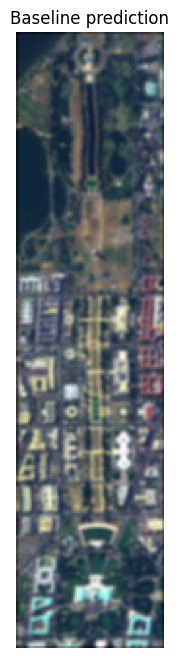

In [12]:
visualize_hsi(prediction, bands=rgb_channels, title="Baseline prediction")

## Summary

This notebook demonstrated the basic HyperBench workflow:

- load a scene
- normalize it
- generate LR HSI and HR MSI
- run a reconstruction pipeline
- evaluate the reconstruction

The same structure extends naturally to real models and larger experiment suites.